In [2]:
!pip install -q monai nibabel tqdm matplotlib kagglehub surface-distance scikit-image plotly pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.9 MB/s eta 0:00:00


In [3]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("muhammedkerem/brain-hemorrhage-segmentation-3d-data")
print("Dataset path:", path)

root = Path(path) / "Dataset" / "nifti_files_last_data" / "nifti_files_last_data"

train_img_dir = root / "TrainVolumes"
train_lab_dir = root / "TrainSegmentation"
test_img_dir  = root / "TestVolumes"
test_lab_dir  = root / "TestSegmentation"

print("Root:", root)
print("TrainVolumes exists:", train_img_dir.exists())
print("TrainSegmentation exists:", train_lab_dir.exists())
print("TestVolumes exists:", test_img_dir.exists())
print("TestSegmentation exists:", test_lab_dir.exists())

Using Colab cache for faster access to the 'brain-hemorrhage-segmentation-3d-data' dataset.
Dataset path: /kaggle/input/brain-hemorrhage-segmentation-3d-data
Root: /kaggle/input/brain-hemorrhage-segmentation-3d-data/Dataset/nifti_files_last_data/nifti_files_last_data
TrainVolumes exists: True
TrainSegmentation exists: True
TestVolumes exists: True
TestSegmentation exists: True


In [4]:
def make_pairs(img_dir, lab_dir):
    imgs = sorted(img_dir.glob("*.nii"))
    labs = {p.name: p for p in lab_dir.glob("*.nii")}
    pairs = []
    for img in imgs:
        if img.name in labs:
            pairs.append({
                "image": str(img),
                "label": str(labs[img.name]),
                "name": img.name
            })
    return pairs

train_pairs = make_pairs(train_img_dir, train_lab_dir)
test_pairs  = make_pairs(test_img_dir, test_lab_dir)

print("Train:", len(train_pairs))
print("Test:", len(test_pairs))
print("Example:", train_pairs[0])

Train: 215
Test: 50
Example: {'image': '/kaggle/input/brain-hemorrhage-segmentation-3d-data/Dataset/nifti_files_last_data/nifti_files_last_data/TrainVolumes/cerebral_0_0_0.nii', 'label': '/kaggle/input/brain-hemorrhage-segmentation-3d-data/Dataset/nifti_files_last_data/nifti_files_last_data/TrainSegmentation/cerebral_0_0_0.nii', 'name': 'cerebral_0_0_0.nii'}


In [5]:
import nibabel as nib
import numpy as np

# Check label stats across a few samples
print("Label statistics (first 10 train samples):")
for i, pair in enumerate(train_pairs[:10]):
    lab = nib.load(pair["label"]).get_fdata()
    total = lab.size
    fg = (lab > 0).sum()
    ratio = fg / total * 100
    print(f"  {pair['name']:30s}  shape={lab.shape}  fg_voxels={fg:>7d}  fg_ratio={ratio:.3f}%")

lab = nib.load(train_pairs[0]["label"]).get_fdata()
print(f"\nUnique label values: {np.unique(lab)}")

Label statistics (first 10 train samples):
  cerebral_0_0_0.nii              shape=(512, 512, 23)  fg_voxels=   1095  fg_ratio=0.018%
  cerebral_100_0_0.nii            shape=(512, 512, 23)  fg_voxels=   1646  fg_ratio=0.027%
  cerebral_101_0_0.nii            shape=(512, 512, 23)  fg_voxels=   7176  fg_ratio=0.119%
  cerebral_102_0_0.nii            shape=(512, 512, 23)  fg_voxels=   9109  fg_ratio=0.151%
  cerebral_103_0_0.nii            shape=(512, 512, 23)  fg_voxels=   5722  fg_ratio=0.095%
  cerebral_104_0_0.nii            shape=(512, 512, 23)  fg_voxels=  20318  fg_ratio=0.337%
  cerebral_105_0_0.nii            shape=(512, 512, 23)  fg_voxels=   8204  fg_ratio=0.136%
  cerebral_106_0_0.nii            shape=(512, 512, 23)  fg_voxels=  36643  fg_ratio=0.608%
  cerebral_107_0_0.nii            shape=(512, 512, 23)  fg_voxels=    629  fg_ratio=0.010%
  cerebral_108_0_0.nii            shape=(512, 512, 23)  fg_voxels=  14828  fg_ratio=0.246%

Unique label values: [0. 1.]


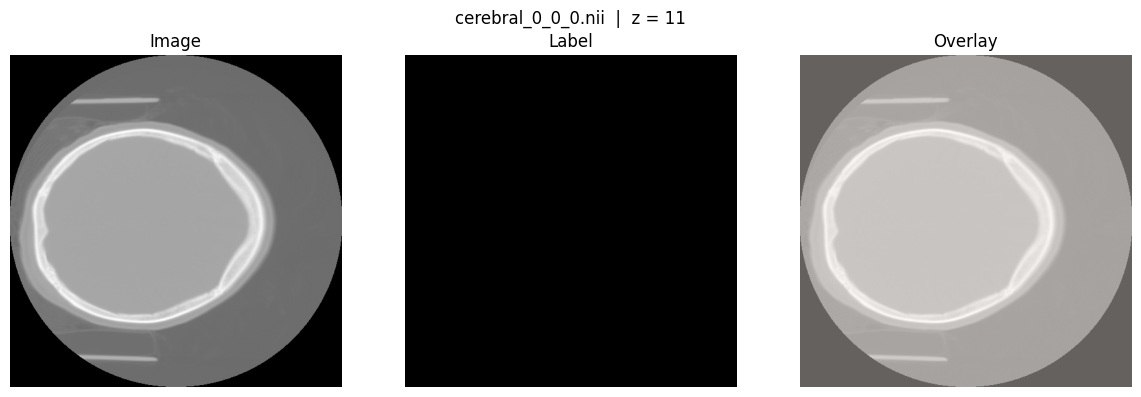

In [6]:
import matplotlib.pyplot as plt

sample = train_pairs[0]
img_data = nib.load(sample["image"]).get_fdata()
lab_data = nib.load(sample["label"]).get_fdata()

z_mid = img_data.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_data[:, :, z_mid], cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(lab_data[:, :, z_mid], cmap="gray")
axes[1].set_title("Label")
axes[1].axis("off")

axes[2].imshow(img_data[:, :, z_mid], cmap="gray")
axes[2].imshow(lab_data[:, :, z_mid], cmap="Reds", alpha=0.4)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.suptitle(f"{sample['name']}  |  z = {z_mid}")
plt.tight_layout()
plt.show()

## 6. Setup Transforms, Model & Optimizer (Improved)

In [ ]:
import torch
import pandas as pd
from tqdm import tqdm

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    ScaleIntensityRangePercentilesd, CropForegroundd,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d,
    RandGaussianNoised, RandGaussianSmoothd,
    EnsureTyped, Lambdad
)
from monai.data import CacheDataset, DataLoader
from monai.networks.nets import SegResNet
from monai.losses import DiceFocalLoss
from monai.inferers import sliding_window_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===== HYPERPARAMETERS (improved) =====
PATCH = (128, 128, 16)       # Smaller patch -> more diverse crops
MAX_EPOCHS = 50              # More epochs for convergence
LR = 3e-4                    # Higher initial LR
INIT_FILTERS = 32            # Doubled model capacity
POS_NEG_RATIO = (4, 1)       # 4:1 foreground-to-background sampling
NUM_SAMPLES = 4              # 4 patches per volume per epoch
CACHE_RATE = 0.3             # Cache more data in memory

def to_binary(x):
    return (x > 0).astype(x.dtype)

train_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRangePercentilesd(
        keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True
    ),
    Lambdad(keys=["label"], func=to_binary),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH,
        pos=POS_NEG_RATIO[0],
        neg=POS_NEG_RATIO[1],
        num_samples=NUM_SAMPLES
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.3, max_k=3),
    RandGaussianNoised(keys=["image"], prob=0.15, mean=0.0, std=0.05),
    RandGaussianSmoothd(keys=["image"], prob=0.1, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
    EnsureTyped(keys=["image", "label"]),
])

val_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRangePercentilesd(
        keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True
    ),
    Lambdad(keys=["label"], func=to_binary),
    EnsureTyped(keys=["image", "label"]),
])

train_ds = CacheDataset(train_pairs, transform=train_tf, cache_rate=CACHE_RATE)
val_ds   = CacheDataset(test_pairs, transform=val_tf, cache_rate=CACHE_RATE)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# SegResNet with more capacity
model = SegResNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    init_filters=INIT_FILTERS,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

# DiceFocalLoss
loss_fn = DiceFocalLoss(
    to_onehot_y=True,
    softmax=True,
    gamma=2.0,    # Focal gamma
    lambda_dice=1.0,
    lambda_focal=1.0,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

# Warmup for 5 epochs then cosine decay
warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs  # Linear warmup
    else:
        import math
        progress = (epoch - warmup_epochs) / (MAX_EPOCHS - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))  # Cosine decay to 0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Patch: {PATCH}, Epochs: {MAX_EPOCHS}, LR: {LR}")
print(f"Pos:Neg = {POS_NEG_RATIO[0]}:{POS_NEG_RATIO[1]}, Samples/vol: {NUM_SAMPLES}")

history = {
    "train_loss": [], "val_loss": [],
    "dice": [], "iou": [], "precision": [],
    "recall": [], "specificity": [], "accuracy": [],
    "lr": [],
}

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Device: cuda


Loading dataset: 100%|██████████| 15/15 [00:10<00:00,  1.45it/s]


Model params: 18,796,002
Patch: (128, 128, 16), Epochs: 50, LR: 0.0003
Pos:Neg = 4:1, Samples/vol: 4


## 7. Metric Helper Functions

In [8]:
import numpy as np

def binary_from_logits(logits):
    """logits: (B,2,H,W,D) -> binary mask: (B,H,W,D)"""
    return torch.argmax(logits, dim=1)

def compute_batch_metrics(pred_bin, gt_bin):
    """
    Compute segmentation metrics.
    Accepts torch tensors or numpy arrays, any shape.
    """
    if isinstance(pred_bin, np.ndarray):
        pred_bin = torch.from_numpy(pred_bin)
    if isinstance(gt_bin, np.ndarray):
        gt_bin = torch.from_numpy(gt_bin)

    pred = pred_bin.bool()
    gt = gt_bin.bool()

    tp = torch.logical_and(pred, gt).sum().item()
    fp = torch.logical_and(pred, ~gt).sum().item()
    fn = torch.logical_and(~pred, gt).sum().item()
    tn = torch.logical_and(~pred, ~gt).sum().item()

    dice        = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou         = tp / (tp + fp + fn + 1e-8)
    precision   = tp / (tp + fp + 1e-8)
    recall      = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8)

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "accuracy": float(accuracy),
    }

print("Metric functions defined.")

Metric functions defined.


## 8. Training Loop

In [9]:
best_dice = -1.0
patience_counter = 0
PATIENCE = 15  # Early stopping patience

for epoch in range(1, MAX_EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [train]", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / max(1, len(train_loader))
    history["train_loss"].append(train_loss)

    # --- Validate ---
    model.eval()
    val_loss_sum = 0.0
    n_val = 0
    total_tp = total_fp = total_fn = total_tn = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]", leave=False):
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = sliding_window_inference(
                    images, roi_size=PATCH, sw_batch_size=2, predictor=model
                )
                val_loss = loss_fn(logits, labels)

            val_loss_sum += val_loss.item()
            n_val += 1

            pred_bin = binary_from_logits(logits)
            gt_bin = (labels[:, 0] > 0.5).long()

            m = compute_batch_metrics(pred_bin, gt_bin)
            total_tp += m["tp"]
            total_fp += m["fp"]
            total_fn += m["fn"]
            total_tn += m["tn"]

    val_loss_mean = val_loss_sum / max(1, n_val)

    dice        = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + 1e-8)
    iou         = total_tp / (total_tp + total_fp + total_fn + 1e-8)
    precision   = total_tp / (total_tp + total_fp + 1e-8)
    recall      = total_tp / (total_tp + total_fn + 1e-8)
    specificity = total_tn / (total_tn + total_fp + 1e-8)
    accuracy    = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + 1e-8)

    current_lr = optimizer.param_groups[0]["lr"]

    history["val_loss"].append(float(val_loss_mean))
    history["dice"].append(float(dice))
    history["iou"].append(float(iou))
    history["precision"].append(float(precision))
    history["recall"].append(float(recall))
    history["specificity"].append(float(specificity))
    history["accuracy"].append(float(accuracy))
    history["lr"].append(float(current_lr))

    print(
        f"Epoch {epoch:>2d}: "
        f"train={train_loss:.4f}  val={val_loss_mean:.4f}  "
        f"dice={dice:.4f}  iou={iou:.4f}  "
        f"prec={precision:.4f}  rec={recall:.4f}  "
        f"spec={specificity:.4f}  acc={accuracy:.4f}  "
        f"lr={current_lr:.2e}"
    )

    if dice > best_dice:
        best_dice = float(dice)
        torch.save(model.state_dict(), "best_segresnet_binary.pt")
        print(f"  -> Saved best model (Dice = {best_dice:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

    scheduler.step()

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv("training_history.csv", index=False)
print(f"\nTraining complete. Best Dice: {best_dice:.4f}")
print("Saved training_history.csv")

Epoch 1/50 [train]:   2%|▏         | 4/215 [00:04<02:38,  1.33it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
Epoch 1/50 [train]:   4%|▎         | 8/215 [00:05<01:21,  2.55it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
Epoch 1/50 [val]:   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered interna

Epoch  1: train=0.5645  val=0.5569  dice=0.0000  iou=0.0000  prec=0.0000  rec=0.0000  spec=1.0000  acc=0.9966  lr=6.00e-05
  -> Saved best model (Dice = 0.0000)


Epoch 2/50 [train]:   1%|▏         | 3/215 [00:02<02:13,  1.59it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
Epoch 2/50 [train]:  13%|█▎        | 27/215 [00:15<01:29,  2.10it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(


Epoch  2: train=0.5522  val=0.5448  dice=0.0000  iou=0.0000  prec=0.0000  rec=0.0000  spec=1.0000  acc=0.9966  lr=1.20e-04


Epoch 3/50 [train]:   1%|          | 2/215 [00:02<03:58,  1.12s/it]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(


...

Epoch 45: train=0.3919  val=0.4338  dice=0.3035  iou=0.1789  prec=0.2300  rec=0.4461  spec=0.9950  acc=0.9931  lr=1.30e-05


Epoch 46/50 [train]:   1%|          | 2/215 [00:02<03:12,  1.11it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
Epoch 46/50 [train]:   8%|▊         | 18/215 [00:11<01:35,  2.05it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(


Epoch 46: train=0.3999  val=0.4359  dice=0.2962  iou=0.1739  prec=0.2216  rec=0.4467  spec=0.9947  acc=0.9929  lr=9.05e-06


Epoch 47/50 [train]:   0%|          | 0/215 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
Epoch 47/50 [train]:   2%|▏         | 5/215 [00:03<01:36,  2.19it/s]/usr/local/lib/python3.12/dist-packages/monai/transforms/utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 6029312, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(


Epoch 47: train=0.3923  val=0.4364  dice=0.2922  iou=0.1711  prec=0.2155  rec=0.4540  spec=0.9944  acc=0.9926  lr=5.81e-06
  -> Early stopping at epoch 47 (no improvement for 15 epochs)

Training complete. Best Dice: 0.3075
Saved training_history.csv


## 9. Plot Training Curves

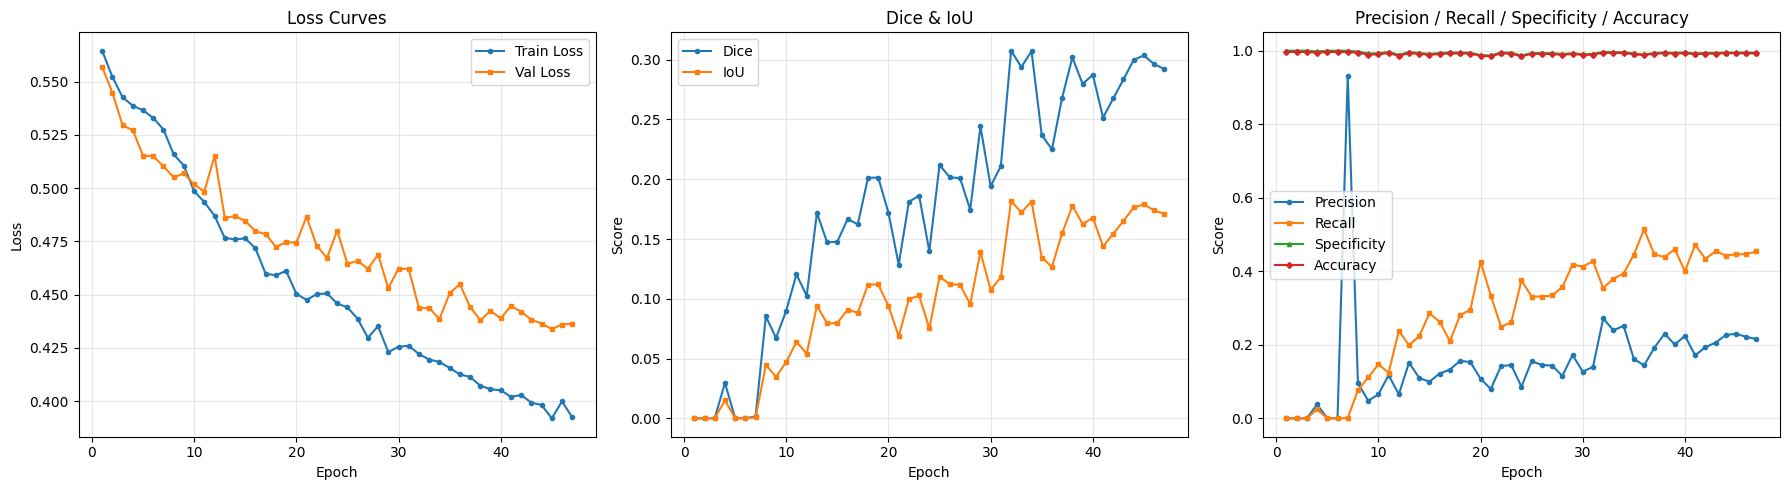

Saved training_curves.png


In [10]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=3)
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="s", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice / IoU
axes[1].plot(epochs_range, history["dice"], label="Dice", marker="o", markersize=3)
axes[1].plot(epochs_range, history["iou"], label="IoU", marker="s", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Dice & IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision / Recall / Specificity / Accuracy
axes[2].plot(epochs_range, history["precision"], label="Precision", marker="o", markersize=3)
axes[2].plot(epochs_range, history["recall"], label="Recall", marker="s", markersize=3)
axes[2].plot(epochs_range, history["specificity"], label="Specificity", marker="^", markersize=3)
axes[2].plot(epochs_range, history["accuracy"], label="Accuracy", marker="D", markersize=3)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].set_title("Precision / Recall / Specificity / Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_curves.png")

## 10. Load Best Model

In [11]:
model = SegResNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    init_filters=INIT_FILTERS,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

model.load_state_dict(torch.load("best_segresnet_binary.pt", map_location=device, weights_only=True))
model.eval()
print("Loaded best_segresnet_binary.pt")

Loaded best_segresnet_binary.pt


## 11. Inference on One Case

In [12]:
import nibabel as nib
import numpy as np

def preprocess_image(nifti_path):
    nii = nib.load(nifti_path)
    img = nii.get_fdata().astype(np.float32)
    lo, hi = np.percentile(img, [0.5, 99.5])
    img_n = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)
    return nii, img_n

def infer_volume(img_n):
    x = torch.from_numpy(img_n).unsqueeze(0).unsqueeze(0).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast("cuda", dtype=torch.float16):
                logits = sliding_window_inference(x, roi_size=PATCH, sw_batch_size=2, predictor=model)
        else:
            logits = sliding_window_inference(x, roi_size=PATCH, sw_batch_size=2, predictor=model)
    pred = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)
    return pred

# Pick a test sample with significant hemorrhage
sample = test_pairs[0]
nii, img_n = preprocess_image(sample["image"])
img = nii.get_fdata().astype(np.float32)
gt = nib.load(sample["label"]).get_fdata().astype(np.float32)
gt_bin = (gt > 0).astype(np.uint8)

pred = infer_volume(img_n)
pred_bin = (pred > 0).astype(np.uint8)

print("Pred shape:", pred.shape)
print("Pred unique:", np.unique(pred))

nib.save(
    nib.Nifti1Image(pred.astype(np.uint8), affine=nii.affine, header=nii.header),
    "prediction_mask.nii"
)
print("Saved prediction_mask.nii")

m = compute_batch_metrics(pred_bin, gt_bin)
print(f"\nSingle-case metrics for '{sample['name']}':")
for k, v in m.items():
    if k not in ('tp', 'fp', 'fn', 'tn'):
        print(f"  {k:>12s}: {v:.4f}")

Pred shape: (512, 512, 23)
Pred unique: [0 1]
Saved prediction_mask.nii

Single-case metrics for 'cerebral_161_0_0.nii':
          dice: 0.0000
           iou: 0.0000
     precision: 0.0000
        recall: 0.0000
   specificity: 0.9993
      accuracy: 0.9993


## 12. Visual Comparison (TP / FP / FN overlay)

Slices shown: [4]


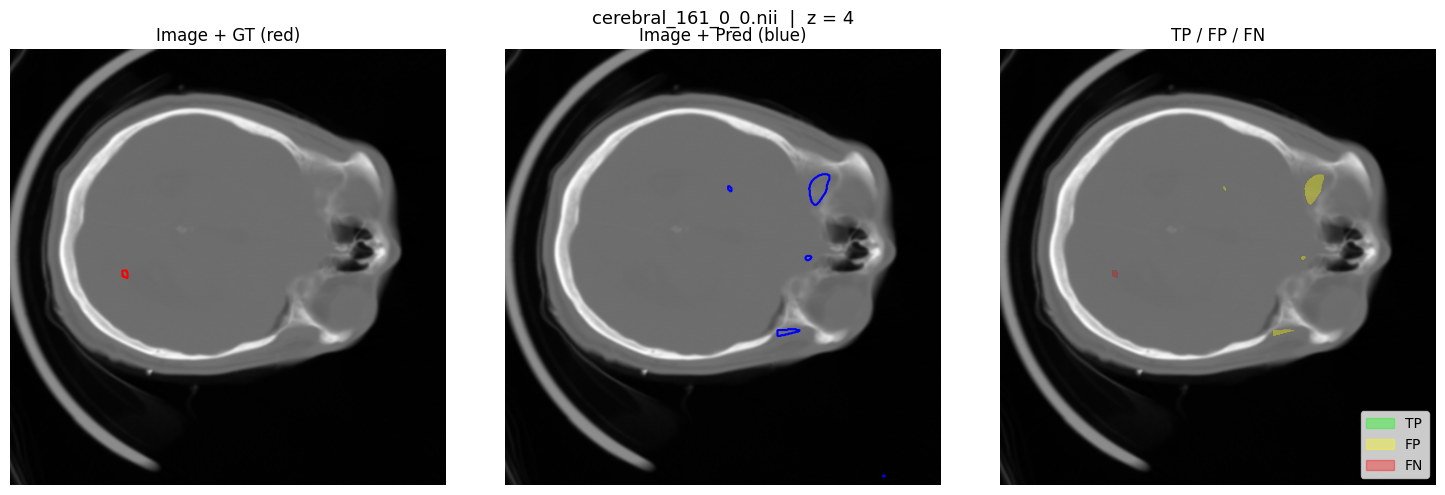

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

H, W, D = gt_bin.shape

areas = gt_bin.reshape(-1, D).sum(axis=0)
top_z = np.argsort(-areas)[:3]
top_z = [int(z) for z in top_z if areas[z] > 0]

if not top_z:
    top_z = [int(pred_bin.reshape(-1, pred_bin.shape[2]).sum(axis=0).argmax())]

print("Slices shown:", top_z)

def show_one(z):
    im2d = img[:, :, z]
    gt2d = gt_bin[:, :, z]
    pr2d = pred_bin[:, :, z]

    tp = (pr2d == 1) & (gt2d == 1)
    fp = (pr2d == 1) & (gt2d == 0)
    fn = (pr2d == 0) & (gt2d == 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(im2d, cmap="gray")
    if gt2d.any():
        axes[0].contour(gt2d.astype(float), levels=[0.5], colors="red", linewidths=1.5)
    axes[0].set_title("Image + GT (red)")
    axes[0].axis("off")

    axes[1].imshow(im2d, cmap="gray")
    if pr2d.any():
        axes[1].contour(pr2d.astype(float), levels=[0.5], colors="blue", linewidths=1.5)
    axes[1].set_title("Image + Pred (blue)")
    axes[1].axis("off")

    axes[2].imshow(im2d, cmap="gray")
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    overlay[tp] = [0.0, 1.0, 0.0, 0.35]
    overlay[fp] = [1.0, 1.0, 0.0, 0.35]
    overlay[fn] = [1.0, 0.0, 0.0, 0.35]
    axes[2].imshow(overlay)
    handles = [
        mpatches.Patch(color=(0, 1, 0, 0.35), label="TP"),
        mpatches.Patch(color=(1, 1, 0, 0.35), label="FP"),
        mpatches.Patch(color=(1, 0, 0, 0.35), label="FN"),
    ]
    axes[2].legend(handles=handles, loc="lower right", framealpha=0.8)
    axes[2].set_title("TP / FP / FN")
    axes[2].axis("off")

    plt.suptitle(f"{sample['name']}  |  z = {z}", fontsize=13)
    plt.tight_layout()
    plt.show()

for z in top_z:
    show_one(z)

## 13. Evaluate on Whole Test Set + HD95

In [14]:
import os
import zipfile
from surface_distance import metrics as sd_metrics

def hd95(pred_bin, gt_bin, spacing):
    pred_bool = pred_bin.astype(bool)
    gt_bool = gt_bin.astype(bool)
    if pred_bool.sum() == 0 and gt_bool.sum() == 0:
        return 0.0
    if pred_bool.sum() == 0 or gt_bool.sum() == 0:
        return np.nan
    surf = sd_metrics.compute_surface_distances(gt_bool, pred_bool, spacing_mm=spacing)
    return float(sd_metrics.compute_robust_hausdorff(surf, 95))

out_dir = "pred_test_nifti"
os.makedirs(out_dir, exist_ok=True)

rows = []

for s in tqdm(test_pairs, desc="Evaluating test set"):
    img_nii, img_n = preprocess_image(s["image"])
    gt = nib.load(s["label"]).get_fdata().astype(np.float32)
    gt_b = (gt > 0).astype(np.uint8)

    pred = infer_volume(img_n)
    pred_b = (pred > 0).astype(np.uint8)

    base_metrics = compute_batch_metrics(pred_b, gt_b)

    spacing = tuple(float(x) for x in img_nii.header.get_zooms()[:3])
    base_metrics["hd95"] = hd95(pred_b, gt_b, spacing)
    base_metrics["name"] = s["name"]
    base_metrics["gt_sum"] = int(gt_b.sum())
    base_metrics["pred_sum"] = int(pred_b.sum())

    rows.append(base_metrics)

    pred_nii = nib.Nifti1Image(pred.astype(np.uint8), affine=img_nii.affine, header=img_nii.header)
    nib.save(pred_nii, os.path.join(out_dir, s["name"]))

results_df = pd.DataFrame(rows)
results_df.to_csv("test_metrics_full.csv", index=False)
print("Saved test_metrics_full.csv")
results_df.head(10)

Evaluating test set: 100%|██████████| 50/50 [02:45<00:00,  3.31s/it]

Saved test_metrics_full.csv


,tp,fp,fn,tn,dice,iou,precision,recall,specificity,accuracy,hd95,name,gt_sum,pred_sum
0,0,3957,119,6025236,0.000000,0.000000,0.000000,0.000000,0.999344,0.999324,196.667491,cerebral_161_0_0.nii,119,3957
1,9071,3715,70621,5945905,0.196176,0.108756,0.709448,0.113826,0.999376,0.987671,103.175450,cerebral_162_0_0.nii,79692,12786
2,14657,13030,8699,5992926,0.574300,0.402820,0.529382,0.627548,0.997830,0.996396,46.880188,cerebral_163_0_0.nii,23356,27687
3,0,23858,556,6004898,0.000000,0.000000,0.000000,0.000000,0.996043,0.995951,172.172606,cerebral_164_0_0.nii,556,23858
4,4354,51808,9275,5963875,0.124773,0.066537,0.077526,0.319466,0.991388,0.989869,104.102023,cerebral_165_0_0.nii,13629,56162
5,29890,65205,17709,5916508,0.418938,0.264973,0.314317,0.627954,0.989099,0.986248,104.658614,cerebral_166_0_0.nii,47599,95095
6,0,11012,504,6017796,0.000000,0.000000,0.000000,0.000000,0.998173,0.998090,152.182834,cerebral_167_0_0.nii,504,11012
7,382,9947,670,6018313,0.067129,0.034730,0.036983,0.363118,0.998350,0.998239,122.355533,cerebral_168_0_0.nii,1052,10329
8,13639,33572,27610,5954491,0.308365,0.182288,0.288895,0.330650,0.994394,0.989853,66.076710,cerebral_169_0_0.nii,41249,47211
9,1056,36499,3201,5988556,0.050512,0.025910,0.028119,0.248062,0.993942,0.993416,139.949269,cerebral_170_0_0.nii,4257,37555


## 14. Summary Metrics

In [15]:
def summarize_col(series):
    vals = series.dropna().values
    if len(vals) == 0:
        return {"mean": None, "std": None, "median": None, "min": None, "max": None}
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "median": float(np.median(vals)),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
    }

metric_cols = ["dice", "iou", "precision", "recall", "specificity", "accuracy", "hd95"]
summary = {col: summarize_col(results_df[col]) for col in metric_cols}

summary_df = pd.DataFrame(summary).T
summary_df.index.name = "metric"
print("=" * 60)
print("TEST SET SUMMARY")
print("=" * 60)
print(summary_df.to_string(float_format="{:.4f}".format))
print("=" * 60)

TEST SET SUMMARY
                mean     std   median     min      max
metric                                                
dice          0.1794  0.2058   0.0920  0.0000   0.6832
iou           0.1148  0.1444   0.0482  0.0000   0.5188
precision     0.1824  0.2283   0.0752  0.0000   0.7998
recall        0.2210  0.2263   0.1564  0.0000   0.7236
specificity   0.9968  0.0025   0.9979  0.9891   0.9997
accuracy      0.9946  0.0041   0.9962  0.9860   0.9997
hd95        103.9433 34.5112 102.0578 36.8353 196.6675


## 15. Distribution of Test Metrics

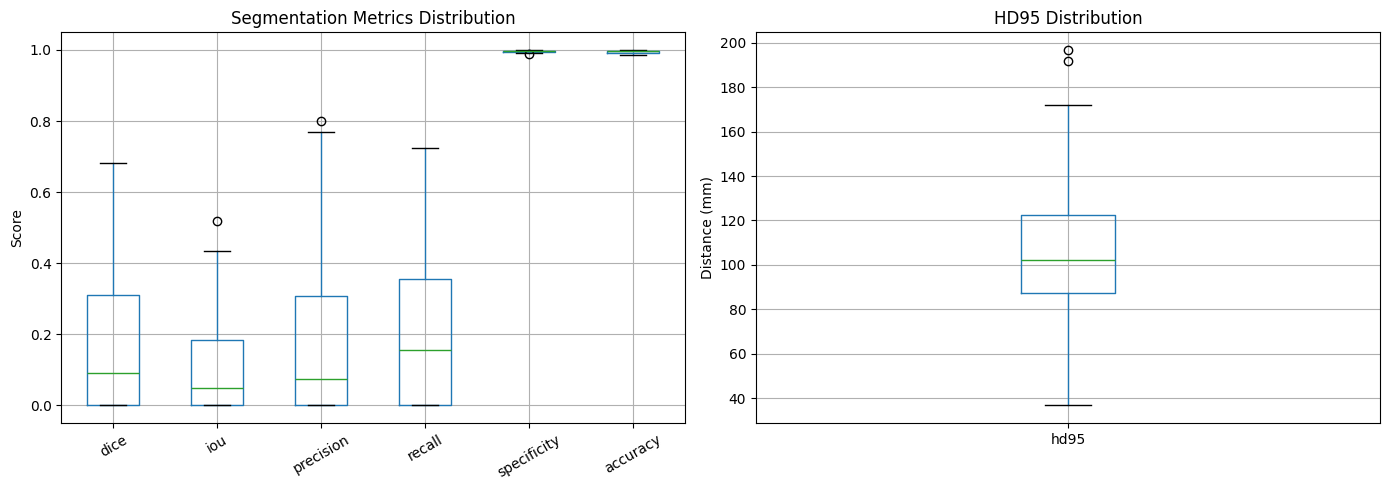

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_cols = ["dice", "iou", "precision", "recall", "specificity", "accuracy"]
results_df[score_cols].boxplot(ax=axes[0], grid=True)
axes[0].set_title("Segmentation Metrics Distribution")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=30)

results_df[["hd95"]].dropna().boxplot(ax=axes[1], grid=True)
axes[1].set_title("HD95 Distribution")
axes[1].set_ylabel("Distance (mm)")

plt.tight_layout()
plt.savefig("test_metrics_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Zip Predictions

In [17]:
zip_path = "pred_test_nifti.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(out_dir):
        zf.write(os.path.join(out_dir, fn), arcname=fn)
print("Saved:", zip_path)

Saved: pred_test_nifti.zip


## 17. 3D Mesh Visualization (GT vs Pred)

In [18]:
from skimage import measure
import plotly.graph_objects as go

best_idx = int(results_df["dice"].idxmax())
name = results_df.loc[best_idx, "name"]
print("Visualizing:", name)

s = next(x for x in test_pairs if x["name"] == name)
img_nii, img_n = preprocess_image(s["image"])
gt_3d = (nib.load(s["label"]).get_fdata() > 0).astype(np.uint8)
pred_3d = nib.load(os.path.join(out_dir, name)).get_fdata().astype(np.uint8)

sx, sy, sz = img_nii.header.get_zooms()[:3]

def mesh_from_mask(mask, level=0.5):
    if mask.sum() == 0:
        return None, None
    verts, faces, _, _ = measure.marching_cubes(mask, level=level)
    verts = np.stack([verts[:, 0] * sx, verts[:, 1] * sy, verts[:, 2] * sz], axis=1)
    return verts, faces

gt_verts, gt_faces = mesh_from_mask(gt_3d)
pr_verts, pr_faces = mesh_from_mask(pred_3d)

fig = go.Figure()

if gt_verts is not None:
    fig.add_trace(go.Mesh3d(
        x=gt_verts[:,0], y=gt_verts[:,1], z=gt_verts[:,2],
        i=gt_faces[:,0], j=gt_faces[:,1], k=gt_faces[:,2],
        opacity=0.35, name="GT", color="red"
    ))

if pr_verts is not None:
    fig.add_trace(go.Mesh3d(
        x=pr_verts[:,0], y=pr_verts[:,1], z=pr_verts[:,2],
        i=pr_faces[:,0], j=pr_faces[:,1], k=pr_faces[:,2],
        opacity=0.35, name="Pred", color="blue"
    ))

fig.update_layout(
    title=f"3D Hemorrhage Mesh: {name}",
    scene=dict(aspectmode="data"),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

Visualizing: cerebral_189_0_0.nii


## 18. Download Outputs (Colab)

In [ ]:

from google.colab import files

files.download("best_segresnet_binary.pt")
files.download("training_history.csv")
files.download("training_curves.png")
files.download("test_metrics_full.csv")
files.download("test_metrics_boxplot.png")
files.download("prediction_mask.nii")
files.download("pred_test_nifti.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>